# Unified API: all inference methods on the same problem

The `lfi` package wraps a wide range of likelihood-free inference (LFI) methods
under a single, consistent interface. Regardless of whether the method is
a simple ABC rejection sampler, a JAX-accelerated SMC, or a deep neural
posterior estimator, the user always calls the same three steps:

```python
method = SomeMethod(prior, simulator, observation)
method.fit(budget=...)
samples = method.sample(nof_samples=...)
```

This notebook demonstrates that uniformity on a 2-D Gaussian noise problem,
in three comparison rounds:

* **Part 1** — ABC-based methods (rejection + SMC, NumPy and JAX) vs R2OMC
* **Part 2** — SBI neural-posterior methods vs R2OMC
* **Part 3** — elfi methods vs R2OMC

---
## Available methods

| Method | Class | Backend | Requires |
|--------|-------|---------|----------|
| ABC Rejection | `ABCRejection` | NumPy | — |
| SMC-ABC | `SMCInference` | NumPy | — |
| ABC Rejection (JAX) | `ABCRejectionJAX` | JAX | — |
| SMC-ABC (JAX) | `SMCInferenceJAX` | JAX | — |
| R2OMC | `R2OMC` | JAX + optax | — |
| R2OMC (multi-obs) | `R2OMCMultiObs` | JAX + optax | — |
| NPE-A (single round) | `NPEASingleRound` | sbi | `pip install sbi` |
| NPE-C (single round) | `NPECSingleRound` | sbi | `pip install sbi` |
| NPE-C (multi round) | `NPECMultiRound` | sbi | `pip install sbi` |
| FMPE (single round) | `FMPESingleRound` | sbi | `pip install sbi` |
| BayesFlow | `BayesFlow` | sbi | `pip install sbi` |
| MC-ABC | `SBI_MCABC` | sbi | `pip install sbi` |
| SMC-ABC (sbi) | `SBI_SMCABC` | sbi | `pip install sbi` |
| Rejection (elfi) | `RejectionSampling` | elfi | `pip install elfi` |
| SMC (elfi) | `SMCRejection` | elfi | `pip install elfi` |

All classes inherit from `InferenceBase` and expose the same
`fit` / `sample` / `fit_and_sample` / `plot_posterior_samples` / `store` interface.

In [1]:
import time
import numpy as np
import jax
import matplotlib.pyplot as plt

from lfi.priors import UniformPrior
from lfi.simulators import GaussianNoise
from lfi.inference.native import ABCRejection, SMCInference, ABCRejectionJAX, SMCInferenceJAX
from lfi.inference.r2omc import R2OMC
from lfi.evaluation import c2st

# optional: sbi backend
try:
    from lfi.inference.sbi import NPEASingleRound, NPECSingleRound, FMPESingleRound
    _HAS_SBI = True
except ImportError:
    _HAS_SBI = False
    print("sbi not installed — Part 2 will be skipped. Install with: pip install sbi")

# optional: elfi backend
try:
    from lfi.inference.elfi import RejectionSampling, SMCRejection
    _HAS_ELFI = True
except ImportError:
    _HAS_ELFI = False
    print("elfi not installed — Part 3 will be skipped. Install with: pip install elfi")

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


---
## Problem setup

$$\theta \sim \mathrm{Uniform}(-3, 3)^2 \qquad y \mid \theta \sim \mathcal{N}(\theta,\, 0.1^2 \cdot I) \qquad y_0 = (1.5,\, 1.5)$$

True posterior: $\theta \mid y_0 \approx \mathcal{N}((1.5, 1.5),\, 0.01 \cdot I)$

**The prior, simulator and observation are defined once and shared across all methods.**

In [2]:
DIM         = 2
SIGMA       = 0.1
OBS         = np.array([[1.5, 1.5]], dtype=np.float32)
BUDGET      = 2_000
NOF_SAMPLES = 500
KEY         = jax.random.PRNGKey(0)

prior = UniformPrior(dim=DIM, low=-3, high=3)
sim   = GaussianNoise(dim=DIM, dim_y=DIM, sigma_noise=SIGMA)

# analytical ground truth
rng = np.random.default_rng(42)
gt_samples = rng.normal(loc=OBS[0], scale=SIGMA, size=(NOF_SAMPLES, DIM)).astype(np.float32)

print(f"prior      : Uniform(-3, 3)^{DIM}")
print(f"simulator  : y = theta + N(0, {SIGMA}^2 I)")
print(f"observation: {OBS}")
print(f"budget     : {BUDGET}  |  samples: {NOF_SAMPLES}")

prior      : Uniform(-3, 3)^2
simulator  : y = theta + N(0, 0.1^2 I)
observation: [[1.5 1.5]]
budget     : 2000  |  samples: 500


---
## The unified API

Every method — regardless of backend — follows this identical pattern:

```python
# 1. instantiate — same constructor signature for all
method = SomeMethod(prior, simulator, observation)

# 2. fit — budget controls compute; optional fit_kwargs for tuning
method.fit(budget=BUDGET, fit_kwargs={...}, verbose=1)

# 3. sample — returns np.ndarray of shape (nof_samples, D)
samples = method.sample(nof_samples=NOF_SAMPLES, verbose=1)

# 4. plot — built-in pairwise posterior plot
method.plot_posterior_samples(samples=samples, samples_gt=gt_samples)

# 5. save — store samples to CSV
method.store(samples, "posterior_samples.csv")
```

The only method-specific part is `fit_kwargs` — hyperparameters that differ per algorithm.

---
## Part 1: ABC-based methods vs R2OMC

Classic likelihood-free methods based on rejection / sequential Monte Carlo,
implemented both in NumPy and JAX, compared against R2OMC.

All methods require **no additional dependencies** beyond the base `lfi` install.

In [3]:
# Define Part 1 methods: (display name, class, fit_kwargs, sample_kwargs)
METHODS_PART1 = [
    (
        "ABCRejection",
        ABCRejection,
        {"quantile": 0.1},
        {},
    ),
    (
        "SMCInference",
        SMCInference,
        {"tolerance_sequence": [2.0, 1.0, 0.5, 0.2]},
        {},
    ),
    (
        "ABCRejectionJAX",
        ABCRejectionJAX,
        {"key": KEY, "quantile": 0.1},
        {},
    ),
    (
        "SMCInferenceJAX",
        SMCInferenceJAX,
        {"key": KEY, "tolerance_sequence": [2.0, 1.0, 0.5, 0.2]},
        {},
    ),
    (
        "R2OMC",
        R2OMC,
        {},
        {},
    ),
]

The loop below is **identical for every method** — this is the API uniformity in action.

In [4]:
results_part1 = {}  # name → {method, samples, t_fit, t_sample, c2st}

for name, cls, fit_kwargs, sample_kwargs in METHODS_PART1:
    print(f"\n{'─'*50}")
    print(f"{name}")
    print(f"{'─'*50}")

    # ── identical 3-line pattern for every method ───────────────────────────
    method = cls(prior, sim, OBS)

    t0 = time.perf_counter()
    method.fit(budget=BUDGET, fit_kwargs=fit_kwargs, verbose=1)
    t_fit = time.perf_counter() - t0

    t0 = time.perf_counter()
    samples = method.sample(nof_samples=NOF_SAMPLES, sample_kwargs=sample_kwargs, verbose=1)
    t_sample = time.perf_counter() - t0
    # ────────────────────────────────────────────────────────────────────────

    score = c2st(gt_samples, samples)
    results_part1[name] = {
        "method": method,
        "samples": samples,
        "t_fit": t_fit,
        "t_sample": t_sample,
        "c2st": score,
    }


──────────────────────────────────────────────────
ABCRejection
──────────────────────────────────────────────────
ABCRejection: 200/2000 samples accepted
ABCRejection: 200 samples returned


 /home/givasile/github/papers/lfi/lfi/inference/native.py:70: UserWarning:Only 200 accepted samples available. Returning all.



──────────────────────────────────────────────────
SMCInference
──────────────────────────────────────────────────
SMCInference: 287 posterior particles after 4 rounds
SMCInference: 287 samples returned


 /home/givasile/github/papers/lfi/lfi/inference/native.py:168: UserWarning:Only 287 accepted samples available. Returning all.



──────────────────────────────────────────────────
ABCRejectionJAX
──────────────────────────────────────────────────
ABCRejectionJAX: 200/2000 samples accepted
ABCRejectionJAX: 200 samples returned


 /home/givasile/github/papers/lfi/lfi/inference/native.py:234: UserWarning:Only 200 accepted samples available. Returning all.



──────────────────────────────────────────────────
SMCInferenceJAX
──────────────────────────────────────────────────
SMCInferenceJAX: 286 posterior particles after 4 rounds
SMCInferenceJAX: 286 samples returned


 /home/givasile/github/papers/lfi/lfi/inference/native.py:324: UserWarning:Only 286 accepted samples available. Returning all.



──────────────────────────────────────────────────
R2OMC
──────────────────────────────────────────────────
Step 1: 2/2 informative dims
Step 2: 2000×1 seeds optimised (4 epochs) | dist 0.0000 ± 0.0000
Step 3: 2000/2000 seeds inside prior
Step 4: 1600 seeds accepted | eps_1=0.0000
Step 5: directions computed (hessian)
Step 6: 1600×1 boxes built | eps_2=0.0033
Step 7: 500 samples returned


### Part 1 — Results summary

In [5]:
header = f"{'Method':<22}  {'mean':>14}  {'std':>14}  {'t_fit':>8}  {'t_samp':>8}  {'C2ST':>6}"
print(header)
print("─" * len(header))

for name, r in results_part1.items():
    s = r["samples"]
    mean_str = np.array2string(s.mean(0), precision=2, separator=",")
    std_str  = np.array2string(s.std(0),  precision=2, separator=",")
    print(
        f"{name:<22}  {mean_str:>14}  {std_str:>14}  "
        f"{r['t_fit']:>7.2f}s  {r['t_sample']:>7.2f}s  {r['c2st']:>6.3f}"
    )

print()
print(f"True posterior mean : {OBS[0]}")
print(f"True posterior std  : [{SIGMA:.2f} {SIGMA:.2f}]")
print(f"C2ST: 0.5 = perfect match, 1.0 = completely different")

Method                            mean             std     t_fit    t_samp    C2ST
──────────────────────────────────────────────────────────────────────────────────
ABCRejection               [1.52,1.53]     [0.54,0.56]     0.00s     0.00s   0.969
SMCInference               [1.5 ,1.49]     [0.13,0.13]     0.00s     0.00s   0.662
ABCRejectionJAX            [1.49,1.47]     [0.51,0.56]     0.68s     0.00s   0.961
SMCInferenceJAX            [1.49,1.5 ]     [0.14,0.13]     2.13s     0.00s   0.667
R2OMC                      [1.49,1.51]     [0.12,0.1 ]     6.29s     0.81s   0.561

True posterior mean : [1.5 1.5]
True posterior std  : [0.10 0.10]
C2ST: 0.5 = perfect match, 1.0 = completely different


### Part 1 — Posterior plots

The same `plot_posterior_samples` call works for every method.

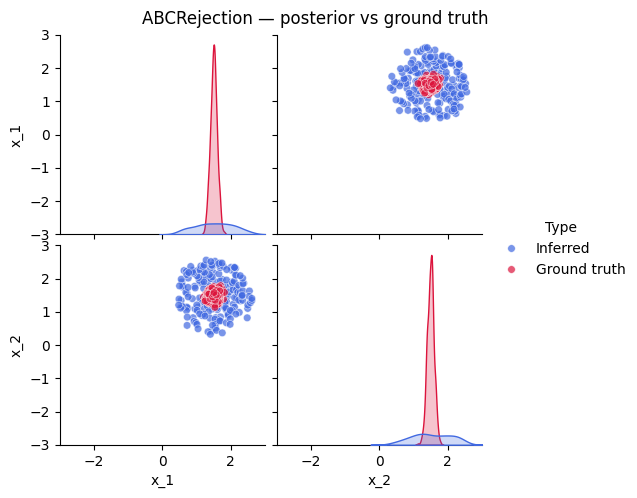

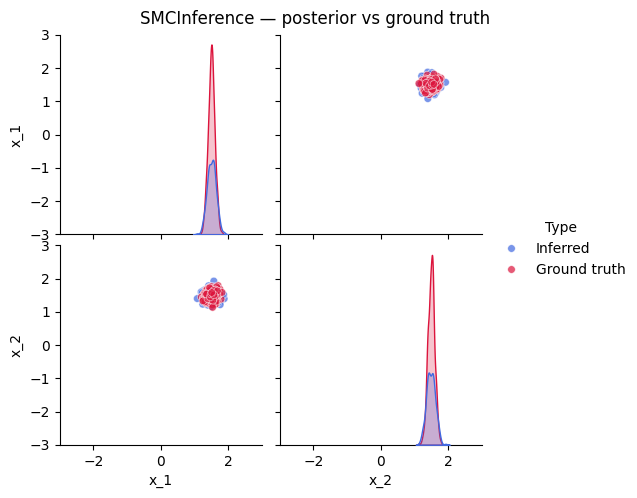

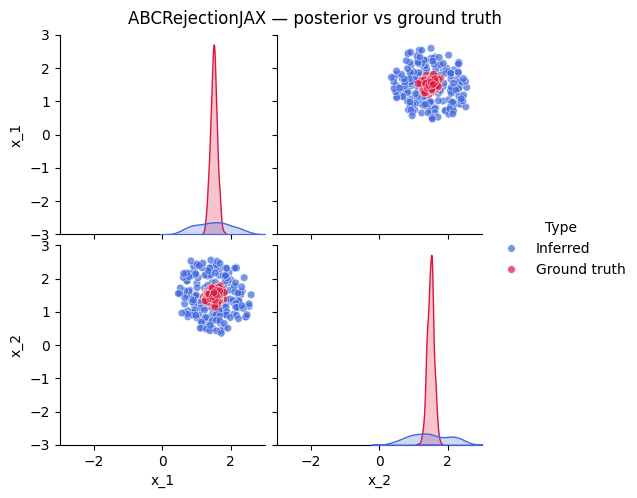

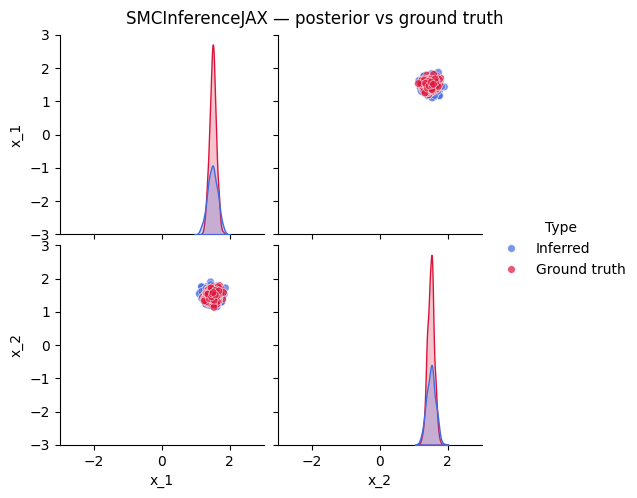

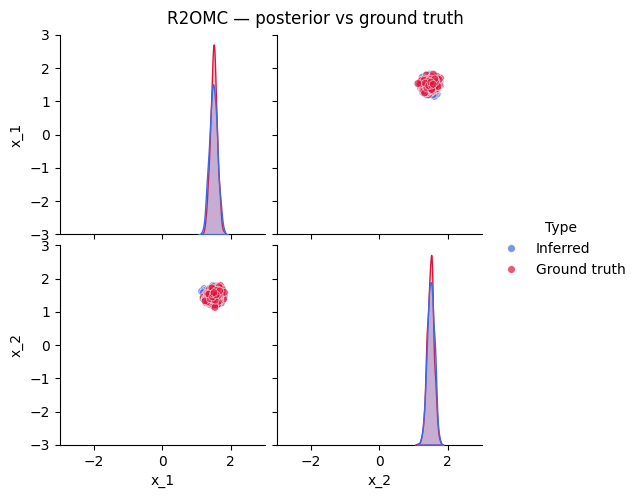

In [6]:
for name, r in results_part1.items():
    r["method"].plot_posterior_samples(
        samples=r["samples"],
        samples_gt=gt_samples,
        limits=[-3, 3],
        title=f"{name} — posterior vs ground truth",
        show=False,
    )
    plt.show()

---
## Part 2: SBI neural-posterior methods vs R2OMC

Neural posterior estimation methods from the [`sbi`](https://sbi-dev.github.io/sbi/) library,
compared against R2OMC under the same budget and API.

| Method | Algorithm |
|--------|-----------|
| `NPEASingleRound` | Fast ε-free posterior estimation (single round) |
| `NPECSingleRound` | Automatic Posterior Transformation / APT (single round) |
| `FMPESingleRound` | Flow Matching Posterior Estimation (single round) |
| `R2OMC` | Region-based rejection OMC (JAX, no neural nets) |

> **Requires:** `pip install sbi`

In [7]:
if not _HAS_SBI:
    print("Skipping Part 2: sbi not installed.")
else:
    # Define Part 2 methods: (display name, class, fit_kwargs, sample_kwargs)
    METHODS_PART2 = [
        (
            "NPEASingleRound",
            NPEASingleRound,
            {},
            {},
        ),
        (
            "NPECSingleRound",
            NPECSingleRound,
            {},
            {},
        ),
        (
            "FMPESingleRound",
            FMPESingleRound,
            {},
            {},
        ),
        (
            "R2OMC",
            R2OMC,
            {},
            {},
        ),
    ]

**The loop is the same three lines** — neural networks and R2OMC are called identically.

In [8]:
if not _HAS_SBI:
    print("Skipping Part 2: sbi not installed.")
else:
    results_part2 = {}  # name → {method, samples, t_fit, t_sample, c2st}

    for name, cls, fit_kwargs, sample_kwargs in METHODS_PART2:
        print(f"\n{'─'*50}")
        print(f"{name}")
        print(f"{'─'*50}")

        # ── identical 3-line pattern for every method ───────────────────────
        method = cls(prior, sim, OBS)

        t0 = time.perf_counter()
        method.fit(budget=BUDGET, fit_kwargs=fit_kwargs, verbose=1)
        t_fit = time.perf_counter() - t0

        t0 = time.perf_counter()
        samples = method.sample(nof_samples=NOF_SAMPLES, sample_kwargs=sample_kwargs, verbose=1)
        t_sample = time.perf_counter() - t0
        # ────────────────────────────────────────────────────────────────────

        score = c2st(gt_samples, samples)
        results_part2[name] = {
            "method": method,
            "samples": samples,
            "t_fit": t_fit,
            "t_sample": t_sample,
            "c2st": score,
        }


──────────────────────────────────────────────────
NPEASingleRound
──────────────────────────────────────────────────


  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 207 epochs.

  0%|          | 0/500 [00:00<?, ?it/s]


──────────────────────────────────────────────────
NPECSingleRound
──────────────────────────────────────────────────


...


──────────────────────────────────────────────────
FMPESingleRound
──────────────────────────────────────────────────


  0%|          | 0/2000 [00:00<?, ?it/s]

 Neural network successfully converged after 260 epochs.

  0%|          | 0/500 [00:00<?, ?it/s]


──────────────────────────────────────────────────
R2OMC
──────────────────────────────────────────────────
Step 1: 2/2 informative dims
Step 2: 2000×1 seeds optimised (4 epochs) | dist 0.0000 ± 0.0000
Step 3: 2000/2000 seeds inside prior
Step 4: 1600 seeds accepted | eps_1=0.0000
Step 5: directions computed (hessian)
Step 6: 1600×1 boxes built | eps_2=0.0033
Step 7: 500 samples returned


### Part 2 — Results summary

In [9]:
if not _HAS_SBI:
    print("Skipping Part 2: sbi not installed.")
else:
    header = f"{'Method':<22}  {'mean':>14}  {'std':>14}  {'t_fit':>8}  {'t_samp':>8}  {'C2ST':>6}"
    print(header)
    print("─" * len(header))

    for name, r in results_part2.items():
        s = r["samples"]
        mean_str = np.array2string(s.mean(0), precision=2, separator=",")
        std_str  = np.array2string(s.std(0),  precision=2, separator=",")
        print(
            f"{name:<22}  {mean_str:>14}  {std_str:>14}  "
            f"{r['t_fit']:>7.2f}s  {r['t_sample']:>7.2f}s  {r['c2st']:>6.3f}"
        )

    print()
    print(f"True posterior mean : {OBS[0]}")
    print(f"True posterior std  : [{SIGMA:.2f} {SIGMA:.2f}]")
    print(f"C2ST: 0.5 = perfect match, 1.0 = completely different")

Method                            mean             std     t_fit    t_samp    C2ST
──────────────────────────────────────────────────────────────────────────────────
NPEASingleRound            [1.49,1.52]     [0.12,0.12]     7.85s     0.01s   0.555
NPECSingleRound            [1.49,1.5 ]     [0.11,0.13]    31.82s     0.04s   0.519
FMPESingleRound            [1.52,1.52]     [0.08,0.09]    11.51s     0.14s   0.580
R2OMC                        [1.5,1.5]     [0.11,0.11]     5.13s     0.56s   0.549

True posterior mean : [1.5 1.5]
True posterior std  : [0.10 0.10]
C2ST: 0.5 = perfect match, 1.0 = completely different


### Part 2 — Posterior plots

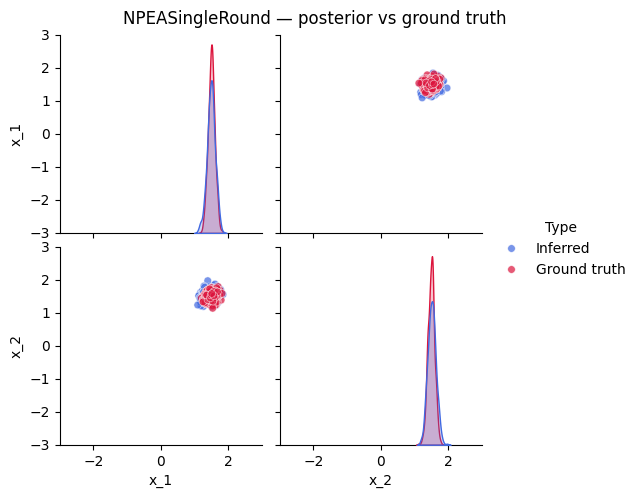

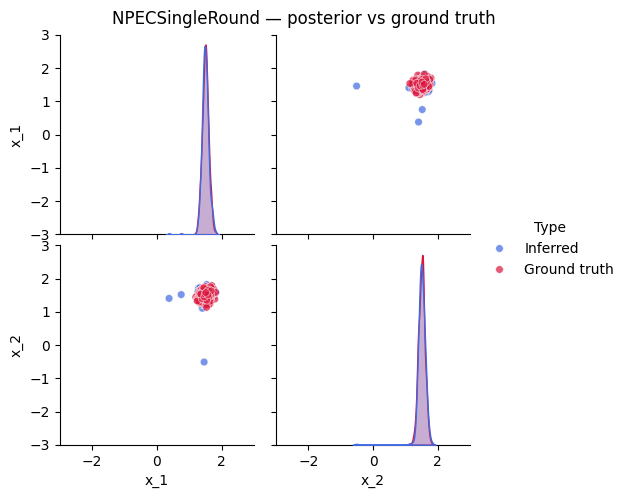

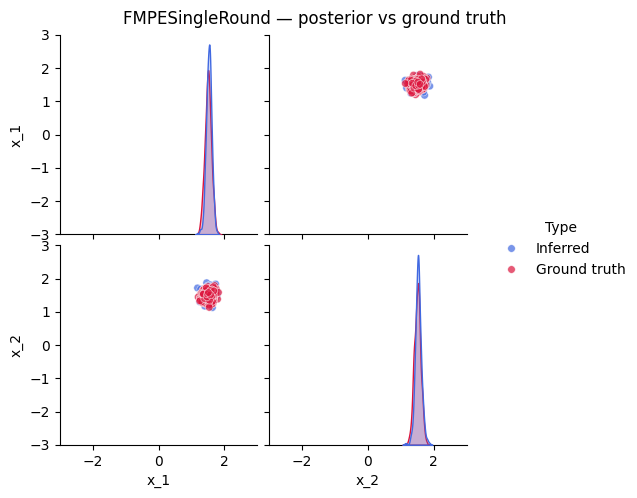

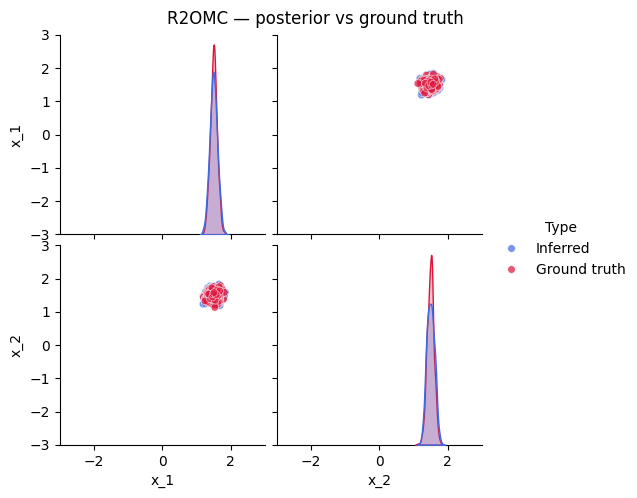

In [10]:
if not _HAS_SBI:
    print("Skipping Part 2: sbi not installed.")
else:
    for name, r in results_part2.items():
        r["method"].plot_posterior_samples(
            samples=r["samples"],
            samples_gt=gt_samples,
            limits=[-3, 3],
            title=f"{name} — posterior vs ground truth",
            show=False,
        )
        plt.show()

---
## Part 3: elfi methods vs R2OMC

The [`elfi`](https://elfi.readthedocs.io/) library provides its own ABC engine.
Here we wrap its rejection and SMC methods behind the same `lfi` interface
and compare them against R2OMC.

| Method | Algorithm |
|--------|-----------|
| `RejectionSampling` | ABC rejection sampler (elfi engine) |
| `SMCRejection` | Sequential Monte Carlo ABC (elfi engine) |
| `R2OMC` | Region-based rejection OMC (JAX, no neural nets) |

> **Requires:** `pip install elfi`

In [11]:
if not _HAS_ELFI:
    print("Skipping Part 3: elfi not installed.")
else:
    # Define Part 3 methods: (display name, class, fit_kwargs, sample_kwargs)
    METHODS_PART3 = [
        (
            "RejectionSampling",
            RejectionSampling,
            {},
            {},
        ),
        (
            "SMCRejection",
            SMCRejection,
            {},
            {"nof_iterations": 4},
        ),
        (
            "R2OMC",
            R2OMC,
            {},
            {},
        ),
    ]

**The loop is unchanged** — elfi methods slot in with the exact same three lines.

In [12]:
if not _HAS_ELFI:
    print("Skipping Part 3: elfi not installed.")
else:
    results_part3 = {}  # name → {method, samples, t_fit, t_sample, c2st}

    for name, cls, fit_kwargs, sample_kwargs in METHODS_PART3:
        print(f"\n{'─'*50}")
        print(f"{name}")
        print(f"{'─'*50}")

        # ── identical 3-line pattern for every method ───────────────────────
        method = cls(prior, sim, OBS)

        t0 = time.perf_counter()
        method.fit(budget=BUDGET, fit_kwargs=fit_kwargs, verbose=1)
        t_fit = time.perf_counter() - t0

        t0 = time.perf_counter()
        samples = method.sample(nof_samples=NOF_SAMPLES, sample_kwargs=sample_kwargs, verbose=1)
        t_sample = time.perf_counter() - t0
        # ────────────────────────────────────────────────────────────────────

        score = c2st(gt_samples, samples)
        results_part3[name] = {
            "method": method,
            "samples": samples,
            "t_fit": t_fit,
            "t_sample": t_sample,
            "c2st": score,
        }


──────────────────────────────────────────────────
RejectionSampling
──────────────────────────────────────────────────
Progress [==================================================] 100.0% Complete

──────────────────────────────────────────────────
SMCRejection
──────────────────────────────────────────────────


AssertionError: Expected 1 dimensions in the output, got 2.

### Part 3 — Results summary

In [ ]:
if not _HAS_ELFI:
    print("Skipping Part 3: elfi not installed.")
else:
    header = f"{'Method':<22}  {'mean':>14}  {'std':>14}  {'t_fit':>8}  {'t_samp':>8}  {'C2ST':>6}"
    print(header)
    print("─" * len(header))

    for name, r in results_part3.items():
        s = r["samples"]
        mean_str = np.array2string(s.mean(0), precision=2, separator=",")
        std_str  = np.array2string(s.std(0),  precision=2, separator=",")
        print(
            f"{name:<22}  {mean_str:>14}  {std_str:>14}  "
            f"{r['t_fit']:>7.2f}s  {r['t_sample']:>7.2f}s  {r['c2st']:>6.3f}"
        )

    print()
    print(f"True posterior mean : {OBS[0]}")
    print(f"True posterior std  : [{SIGMA:.2f} {SIGMA:.2f}]")
    print(f"C2ST: 0.5 = perfect match, 1.0 = completely different")

### Part 3 — Posterior plots

In [ ]:
if not _HAS_ELFI:
    print("Skipping Part 3: elfi not installed.")
else:
    for name, r in results_part3.items():
        r["method"].plot_posterior_samples(
            samples=r["samples"],
            samples_gt=gt_samples,
            limits=[-3, 3],
            title=f"{name} — posterior vs ground truth",
            show=False,
        )
        plt.show()